In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import sys
sys.path.append('..')
from src.mlp_simple import SimpleMLP

In [11]:
def plot_decision_boundary(model, X, y, title="Decision Boundary", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    Z = model.forward(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
    ax.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    
    ax.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdYlBu', 
                        edgecolors='black', s=100, linewidths=1.5)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    
    return ax

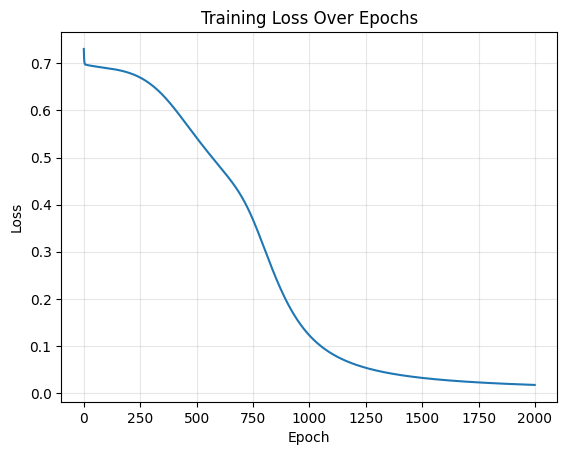

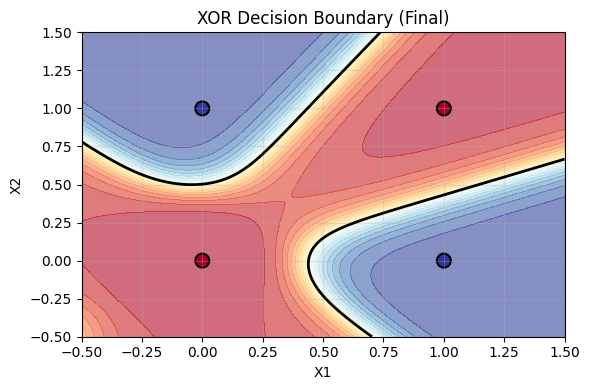

In [12]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

mlp = SimpleMLP(n_input=2, n_hidden=4, n_output=1, 
                learning_rate=0.5, random_state=42)
mlp.fit(X_xor, y_xor, n_epochs=2000, verbose=False)
plt.plot(mlp.loss_history_)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.grid(True, alpha=0.3)
plot_decision_boundary(mlp, X_xor, y_xor, title='XOR Decision Boundary (Final)')
plt.tight_layout()
plt.show()


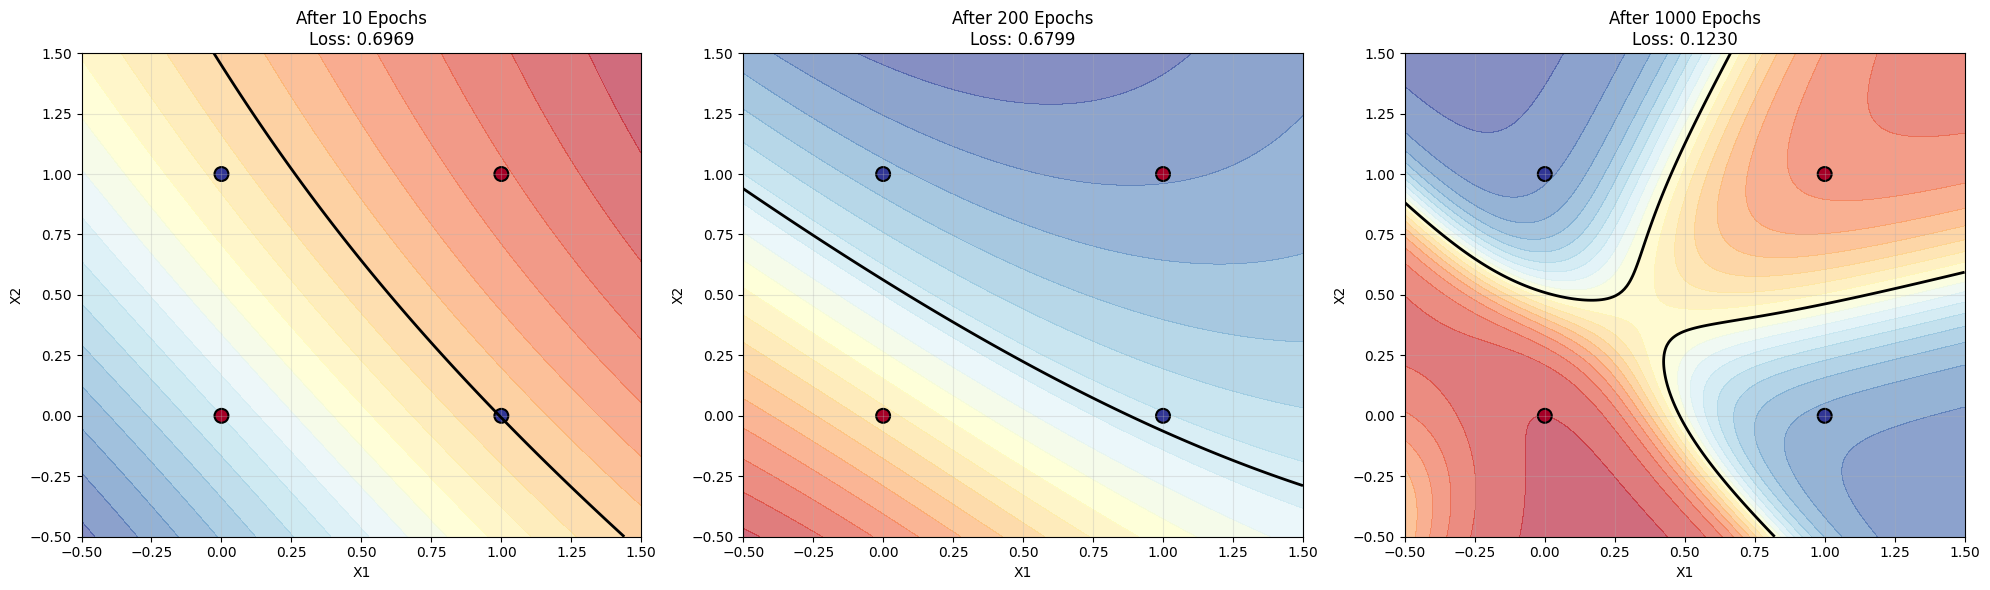

In [10]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

epochs_to_plot = [10, 200, 1000]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.ravel()

for idx, n_epochs in enumerate(epochs_to_plot):
    mlp = SimpleMLP(n_input=2, n_hidden=4, n_output=1, 
                    learning_rate=0.5, random_state=42)
    mlp.fit(X_xor, y_xor, n_epochs=n_epochs, verbose=False)
    
    plot_decision_boundary(mlp, X_xor, y_xor, 
                            title=f'After {n_epochs} Epochs\nLoss: {mlp.loss_history_[-1]:.4f}',
                            ax=axes[idx])

plt.tight_layout()
plt.show()

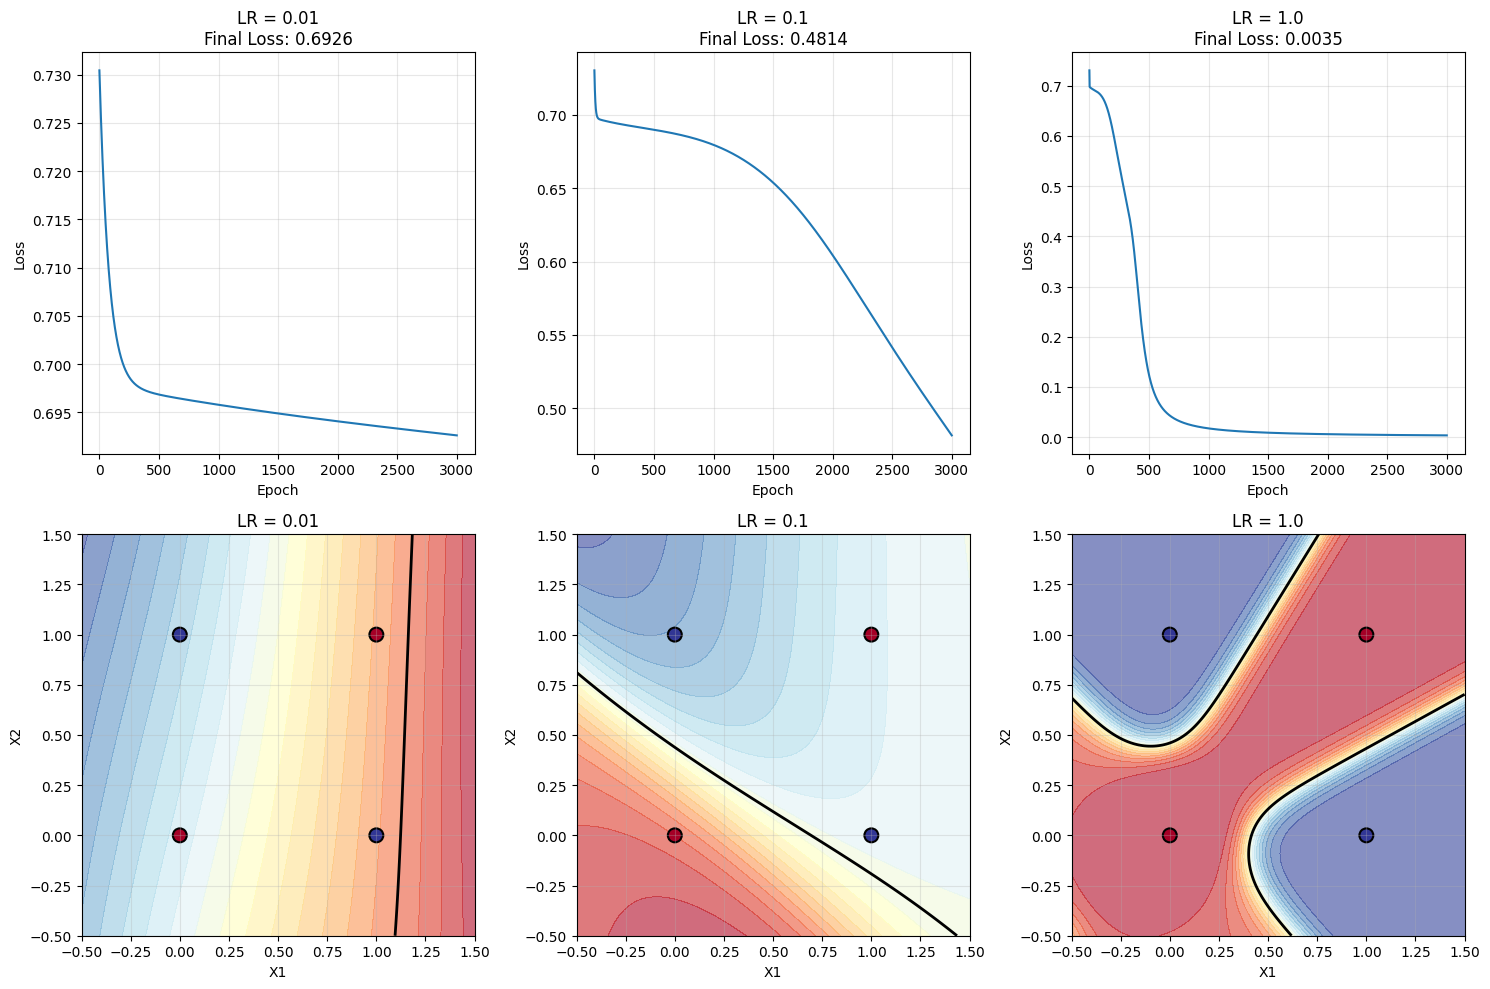

In [5]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

learning_rates = [0.01, 0.1, 1.0]

fig, axes = plt.subplots(2, len(learning_rates), figsize=(15, 10))

for idx, lr in enumerate(learning_rates):
    mlp = SimpleMLP(n_input=2, n_hidden=4, n_output=1, 
                    learning_rate=lr, random_state=42)
    mlp.fit(X_xor, y_xor, n_epochs=3000, verbose=False)
    
    axes[0, idx].plot(mlp.loss_history_)
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].set_title(f'LR = {lr}\nFinal Loss: {mlp.loss_history_[-1]:.4f}')
    axes[0, idx].grid(True, alpha=0.3)
    
    plot_decision_boundary(mlp, X_xor, y_xor, 
                            title=f'LR = {lr}',
                            ax=axes[1, idx])

plt.tight_layout()
plt.show()

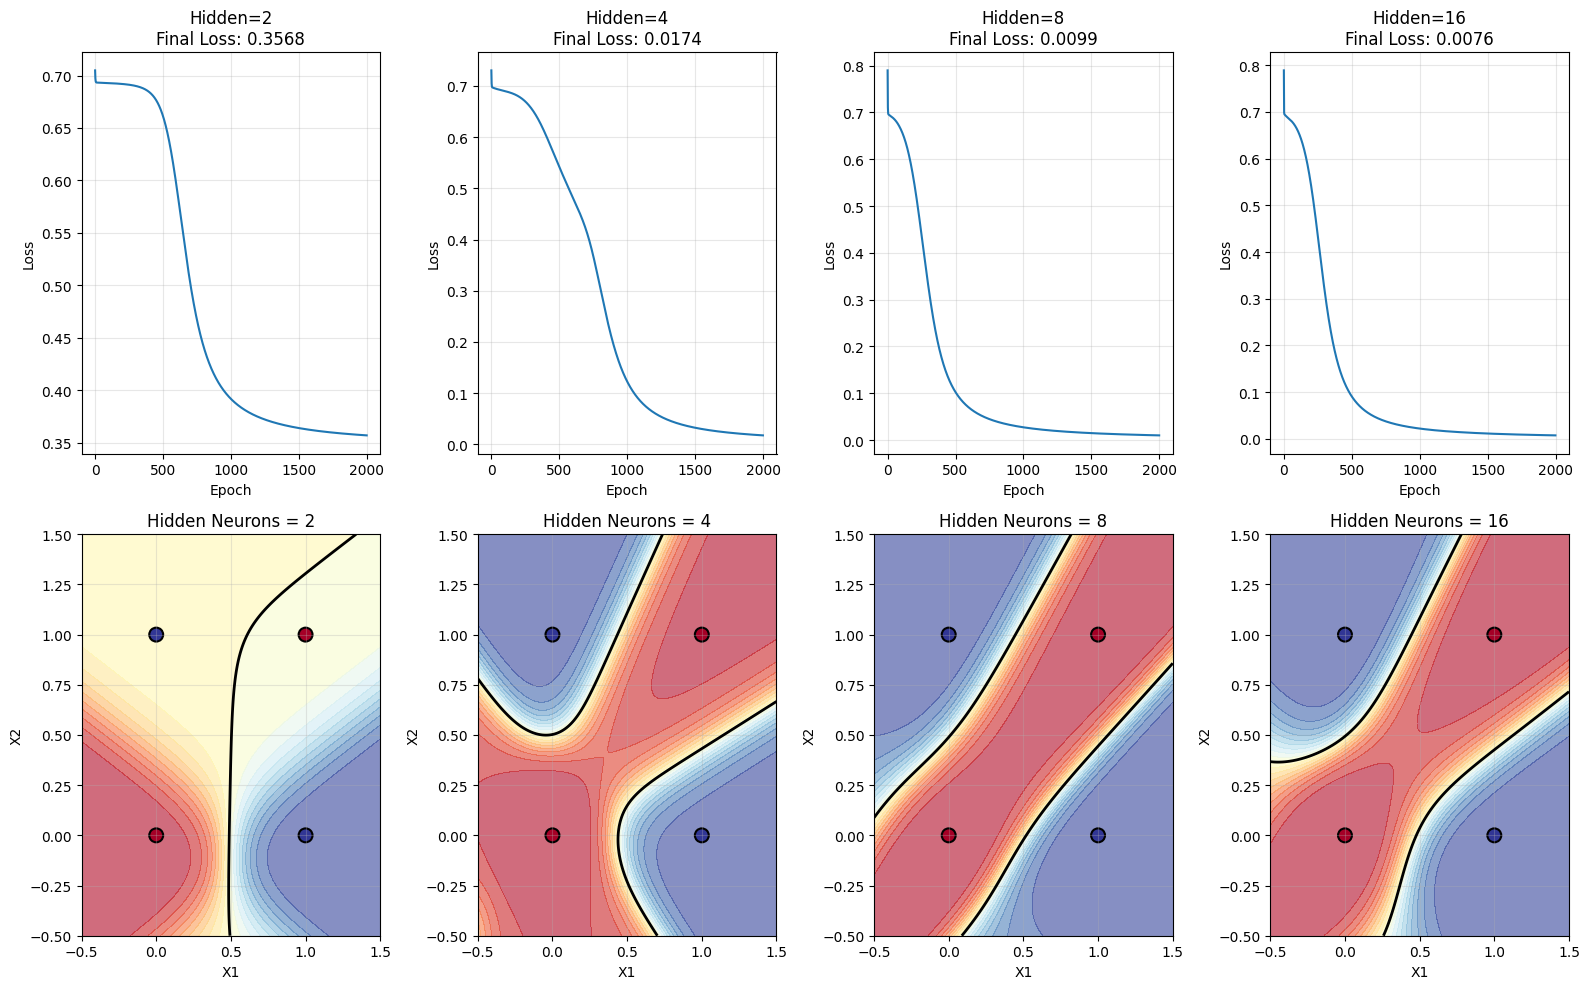

In [6]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

hidden_sizes = [2, 4, 8, 16]

fig, axes = plt.subplots(2, len(hidden_sizes), figsize=(16, 10))

for idx, n_hidden in enumerate(hidden_sizes):
    mlp = SimpleMLP(n_input=2, n_hidden=n_hidden, n_output=1, 
                    learning_rate=0.5, random_state=42)
    mlp.fit(X_xor, y_xor, n_epochs=2000, verbose=False)
    
    axes[0, idx].plot(mlp.loss_history_)
    axes[0, idx].set_xlabel('Epoch')
    axes[0, idx].set_ylabel('Loss')
    axes[0, idx].set_title(f'Hidden={n_hidden}\nFinal Loss: {mlp.loss_history_[-1]:.4f}')
    axes[0, idx].grid(True, alpha=0.3)
    
    plot_decision_boundary(mlp, X_xor, y_xor, 
                            title=f'Hidden Neurons = {n_hidden}',
                            ax=axes[1, idx])
    

plt.tight_layout()
plt.show()


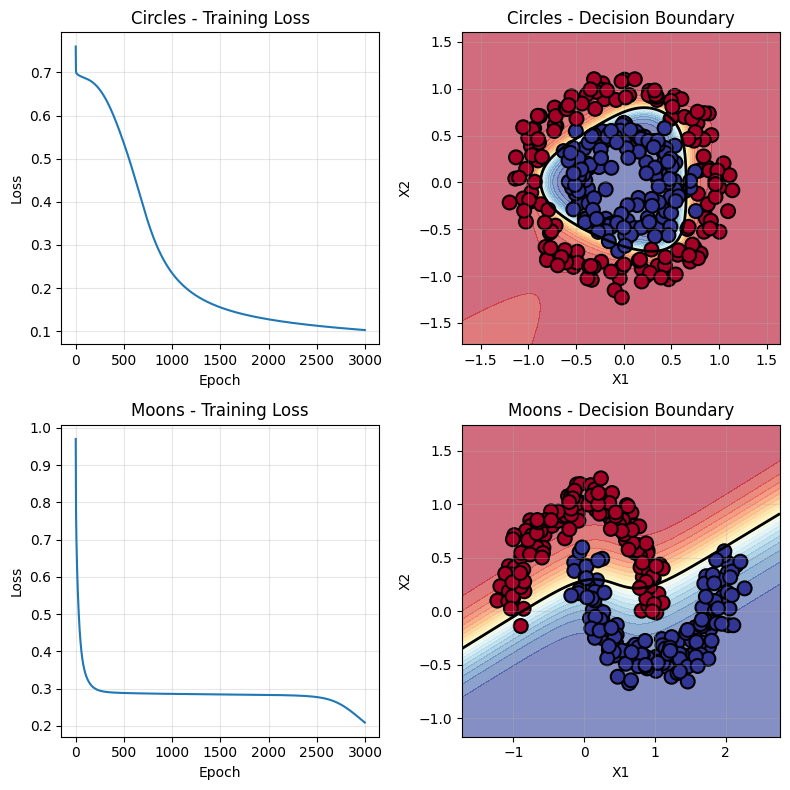

In [15]:
X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.5, random_state=42)
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

datasets = [
    (X_circles, y_circles, "Circles"),
    (X_moons, y_moons, "Moons")
]
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for idx, (X, y, name) in enumerate(datasets):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    y_train = y_train.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)
    mlp = SimpleMLP(n_input=2, n_hidden=8, n_output=1, learning_rate=0.5, random_state=42)
    mlp.fit(X_train, y_train, n_epochs=3000, verbose=False)
    axes[idx, 0].plot(mlp.loss_history_)
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].set_title(f'{name} - Training Loss')
    axes[idx, 0].grid(True, alpha=0.3)
    plot_decision_boundary(mlp, X, y.reshape(-1, 1), title=f'{name} - Decision Boundary', ax=axes[idx, 1])

plt.tight_layout()
plt.show()